In [74]:
# ============================================================
# Cell 1: Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

# Display all columns when printing DataFrames
pd.set_option("display.max_columns", None)

# Display wider tables without wrapping
pd.set_option("display.width", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


In [75]:
# ============================================================
# Cell 2: Load the PTB-XL Metadata
# ============================================================

# Path to the PTB-XL metadata file
database_path = "data/ptb-xl/ptbxl_database.csv"

# Load the metadata into a pandas DataFrame
df = pd.read_csv(database_path)

# Display basic information
print(f"Dataset loaded successfully!")
print(f"Number of records : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

# Display the first five rows
df.head()

Dataset loaded successfully!
Number of records : 21799
Number of columns : 28


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,scp_codes,heart_axis,infarction_stadium1,infarction_stadium2,validated_by,second_opinion,initial_autogenerated_report,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,"{'NORM': 80.0, 'SBRAD': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [76]:
# ============================================================
# Cell 3: Explore the Metadata
# ============================================================

# Display information about the dataset
print("Dataset Information:\n")
df.info()

print("\n" + "="*70)

# Display the data type of every column
print("\nColumn Data Types:\n")
print(df.dtypes)

print("\n" + "="*70)

# Display summary statistics for numerical columns
print("\nSummary Statistics:\n")
display(df.describe())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21799 entries, 0 to 21798
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ecg_id                        21799 non-null  int64  
 1   patient_id                    21799 non-null  float64
 2   age                           21799 non-null  float64
 3   sex                           21799 non-null  int64  
 4   height                        6974 non-null   float64
 5   weight                        9421 non-null   float64
 6   nurse                         20326 non-null  float64
 7   site                          21782 non-null  float64
 8   device                        21799 non-null  object 
 9   recording_date                21799 non-null  object 
 10  report                        21799 non-null  object 
 11  scp_codes                     21799 non-null  object 
 12  heart_axis                    13331 no

,ecg_id,patient_id,age,sex,height,weight,nurse,site,validated_by,strat_fold
count,21799.000000,21799.000000,21799.000000,21799.000000,6974.000000,9421.000000,20326.000000,21782.000000,12421.000000,21799.000000
mean,10926.658379,11250.156521,62.769301,0.479150,166.702323,70.995223,2.291745,1.544945,0.746075,5.503005
std,6302.393366,6235.026404,32.308813,0.499577,10.867321,15.878803,3.254033,4.172883,1.178003,2.874948
min,1.000000,302.000000,2.000000,0.000000,6.000000,5.000000,0.000000,0.000000,0.000000,1.000000
25%,5469.500000,5974.500000,50.000000,0.000000,160.000000,60.000000,0.000000,0.000000,0.000000,3.000000
50%,10926.000000,11419.000000,62.000000,0.000000,166.000000,70.000000,1.000000,1.000000,1.000000,6.000000
75%,16386.500000,16607.500000,72.000000,1.000000,174.000000,80.000000,3.000000,2.000000,1.000000,8.000000
max,21837.000000,21797.000000,300.000000,1.000000,209.000000,250.000000,11.000000,50.000000,11.000000,10.000000


In [78]:
# ============================================================
# Cell 4: Analyze Missing Values
# ============================================================

# Count missing values in each column
missing_count = df.isnull().sum()

# Calculate percentage of missing values
missing_percent = (missing_count / len(df)) * 100

# Create a summary table
missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage (%)": missing_percent.round(2)
})

# Sort columns by highest percentage of missing values
missing_summary = missing_summary.sort_values(
    by="Percentage (%)",
    ascending=False
)

display(missing_summary)

,Missing Values,Percentage (%)
electrodes_problems,21769,99.86
infarction_stadium2,21696,99.53
pacemaker,21508,98.67
burst_noise,21186,97.19
baseline_drift,20201,92.67
extra_beats,19850,91.06
static_noise,18539,85.05
infarction_stadium1,16187,74.26
height,14825,68.01
weight,12378,56.78


In [79]:
# ============================================================
# Cell 5: Explore Age and Sex
# ============================================================

print("Unique values in Sex:")
print(df["sex"].value_counts(dropna=False))

print("\n" + "="*60)

print("Age Statistics:")
print(df["age"].describe())

print("\n" + "="*60)

print("Number of patients with age = 300:")
print((df["age"] == 300).sum())

print("\n" + "="*60)

print("Top 20 most common ages:")
display(df["age"].value_counts().sort_index().tail(20))

Unique values in Sex:
sex
0    11354
1    10445
Name: count, dtype: int64

Age Statistics:
count    21799.000000
mean        62.769301
std         32.308813
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64

Number of patients with age = 300:
293

Top 20 most common ages:


age
71.0     467
72.0     467
73.0     432
74.0     376
75.0     470
76.0     404
77.0     336
78.0     364
79.0     309
80.0     315
81.0     341
82.0     261
83.0     299
84.0     296
85.0     248
86.0     178
87.0     230
88.0     149
89.0      98
300.0    293
Name: count, dtype: int64

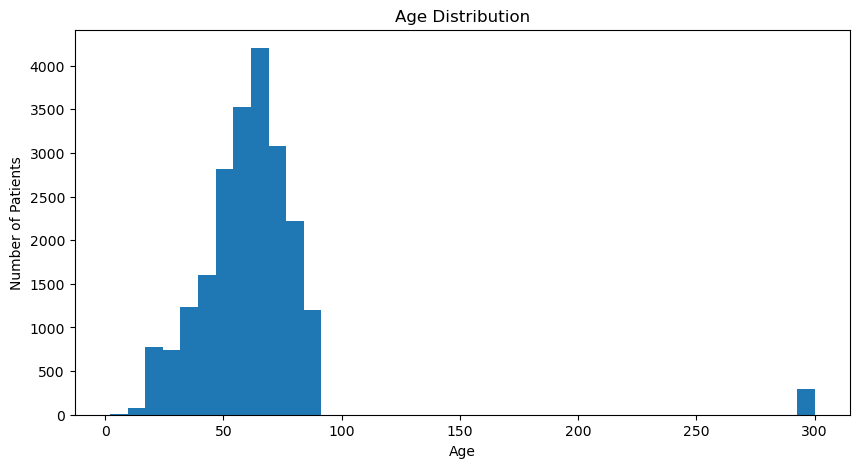

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df["age"], bins=40)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

In [81]:
print("Height Statistics")
display(df["height"].describe())

print("\nWeight Statistics")
display(df["weight"].describe())

print("\nMissing Height:", df["height"].isna().sum())
print("Missing Weight:", df["weight"].isna().sum())

Height Statistics


count    6974.000000
mean      166.702323
std        10.867321
min         6.000000
25%       160.000000
50%       166.000000
75%       174.000000
max       209.000000
Name: height, dtype: float64


Weight Statistics


count    9421.000000
mean       70.995223
std        15.878803
min         5.000000
25%        60.000000
50%        70.000000
75%        80.000000
max       250.000000
Name: weight, dtype: float64


Missing Height: 14825
Missing Weight: 12378


In [82]:
adult_impossible = df[
    ((df["age"] >= 18) & (df["height"] < 100)) |
    ((df["age"] >= 18) & (df["weight"] < 20))
][["ecg_id","age","sex","height","weight"]]

display(adult_impossible)

print("Number of impossible adult records:", len(adult_impossible))

,ecg_id,age,sex,height,weight
4675,4695,82.0,0,175.0,17.0
6038,6059,63.0,0,173.0,5.0
6245,6266,60.0,1,66.0,NaN
6409,6430,46.0,1,67.0,NaN
6460,6481,76.0,0,80.0,NaN
7921,7945,77.0,1,165.0,5.0
9293,9317,64.0,0,6.0,NaN
9360,9384,79.0,1,6.0,NaN
15170,15207,86.0,1,6.0,NaN
15314,15351,84.0,1,90.0,NaN


Number of impossible adult records: 12


In [83]:
temp = df.copy()

temp["BMI"] = temp["weight"] / ((temp["height"]/100)**2)

In [84]:
child_suspicious = temp[
    (temp["age"] < 18) &
    (
        (temp["BMI"] < 10) |
        (temp["BMI"] > 35)
    )
][["ecg_id","age","sex","height","weight","BMI"]]

display(child_suspicious)

print("Suspicious children:", len(child_suspicious))

,ecg_id,age,sex,height,weight,BMI
13634,13666,4.0,1,140.0,15.0,7.653061
18293,18332,17.0,0,178.0,120.0,37.874006


Suspicious children: 2


In [85]:
height_outliers = df[
    (df["height"] < 30) |
    (df["height"] > 230)
][["ecg_id","age","sex","height","weight"]]

display(height_outliers)

,ecg_id,age,sex,height,weight
9293,9317,64.0,0,6.0,NaN
9360,9384,79.0,1,6.0,NaN
15170,15207,86.0,1,6.0,NaN


In [86]:
weight_outliers = df[
    (df["weight"] < 5) |
    (df["weight"] > 250)
][["ecg_id","age","sex","height","weight"]]

display(weight_outliers)

,ecg_id,age,sex,height,weight


In [87]:
# ============================================================
# Remove physiologically impossible demographic records
# ============================================================

original_rows = len(df)

df = df[
    ~(
        (df["height"] < 30) |
        (df["height"] > 230) |

        (df["weight"] < 5) |
        (df["weight"] > 250) |

        (
            (df["age"] >= 18) &
            (df["height"] < 100)
        ) |

        (
            (df["age"] >= 18) &
            (df["weight"] < 20)
        )
    )
].copy()

print("Original rows :", original_rows)
print("Remaining rows:", len(df))
print("Rows removed  :", original_rows - len(df))

Original rows : 21799
Remaining rows: 21787
Rows removed  : 12


In [88]:
for age in range(2, 18):
    n = (df["age"] == age).sum()
    print(f"Age {age}: {n} patients")

Age 2: 1 patients
Age 3: 2 patients
Age 4: 2 patients
Age 5: 2 patients
Age 6: 1 patients
Age 7: 1 patients
Age 8: 3 patients
Age 9: 2 patients
Age 10: 3 patients
Age 11: 4 patients
Age 12: 2 patients
Age 13: 7 patients
Age 14: 11 patients
Age 15: 23 patients
Age 16: 28 patients
Age 17: 41 patients


In [89]:
# ============================================================
# Inspect all pediatric patients (Age < 18)
# ============================================================

children = df[df["age"] < 18].copy()

children["BMI"] = children["weight"] / ((children["height"]/100)**2)

display(
    children[
        ["ecg_id","age","sex","height","weight","BMI"]
    ].sort_values(["age","BMI"])
)

print("Number of pediatric patients:", len(children))

,ecg_id,age,sex,height,weight,BMI
10262,10289,2.0,0,85.0,12.0,16.608997
9712,9736,3.0,1,100.0,16.0,16.000000
1093,1106,3.0,1,NaN,NaN,NaN
13634,13666,4.0,1,140.0,15.0,7.653061
14226,14263,4.0,1,95.0,20.0,22.160665
...,...,...,...,...,...,...
16965,17003,17.0,1,NaN,NaN,NaN
19042,19081,17.0,0,NaN,60.0,NaN
20516,20555,17.0,0,NaN,NaN,NaN
20521,20560,17.0,0,NaN,NaN,NaN


Number of pediatric patients: 133


In [91]:
# ============================================================
# Clean demographic features
# ============================================================

demographics = df[["ecg_id", "age", "sex", "height", "weight"]].copy()

# Replace anonymized age value
demographics["age"] = demographics["age"].replace(300, 89)

# Fill missing height with median
demographics["height"] = demographics["height"].fillna(
    demographics["height"].median()
)

# Fill missing weight with median
demographics["weight"] = demographics["weight"].fillna(
    demographics["weight"].median()
)

print("Demographic features cleaned successfully!")

display(demographics.head())

Demographic features cleaned successfully!


,ecg_id,age,sex,height,weight
0,1,56.0,1,166.0,63.0
1,2,19.0,0,166.0,70.0
2,3,37.0,1,166.0,69.0
3,4,24.0,0,166.0,82.0
4,5,19.0,1,166.0,70.0


In [92]:
print("Missing values after cleaning:\n")

print(demographics.isna().sum())

print("\nAge = 300 remaining:")
print((demographics["age"] == 300).sum())

display(demographics.describe())

Missing values after cleaning:

ecg_id    0
age       0
sex       0
height    0
weight    0
dtype: int64

Age = 300 remaining:
0


,ecg_id,age,sex,height,weight
count,21787.000000,21787.000000,21787.000000,21787.000000,21787.000000
mean,10927.131041,59.926562,0.479093,166.269564,70.438748
std,6303.220286,16.987995,0.499574,5.685982,10.427833
min,1.000000,2.000000,0.000000,85.000000,12.000000
25%,5467.500000,50.000000,0.000000,166.000000,70.000000
50%,10928.000000,62.000000,0.000000,166.000000,70.000000
75%,16388.500000,72.000000,1.000000,166.000000,70.000000
max,21837.000000,89.000000,1.000000,209.000000,250.000000


In [93]:
output_path = "data/ptb-xl/demographic_features.csv"

demographics.to_csv(output_path, index=False)

print(f"Saved demographic features to:\n{output_path}")

Saved demographic features to:
data/ptb-xl/demographic_features.csv
